# Random Forest Classifier | Titanic

**Dataset:** Titanic 
**Problem:** Predict passenger survival -- direct comparison with Logistic Regression and Decision Tree Classifier.

**The classification chain on Titanic is now complete:**
```
 Logistic Regression   -- linear boundary, interpretable coefficients
 Decision Tree         -- non-linear, explicit rules, high variance
 Random Forest         -- ensemble of trees, lower variance, better accuracy
```

**Why Random Forest fixes the Decision Tree problem:**
A single Decision Tree has high variance -- small changes in training data produce completely different trees. Random Forest builds hundreds of trees, each on a different random subset of data and features, then takes a majority vote. The randomness forces trees to be different from each other. Averaging diverse trees cancels out individual errors.

**The two sources of randomness:**
1. Bootstrap sampling -- each tree trains on a random sample with replacement (bagging)
2. Feature subsampling -- at each split, only a random subset of features is considered

**What this notebook covers:**
1. How Random Forest differs from bagging a single tree
2. Out-of-bag (OOB) error -- a free validation set built into the algorithm
3. Training and evaluation -- full comparison with M2 and M4
4. Feature importance -- more stable than single Decision Tree
5. The effect of n_estimators -- when does adding more trees stop helping
6. Permutation importance -- a more reliable alternative



## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Imports ready")

Imports ready


## 1. Load and Preprocess



In [3]:

df = pd.read_csv('../../Datasets/Titanic/Titanic.csv').drop(columns=['Unnamed: 0'])

# Missing values
df['age'] = df.groupby(['pclass','sex'])['age'].transform(
    lambda x: x.fillna(x.median()))
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.drop(columns=['deck'], inplace=True)

# Drop derived/leakage columns
df.drop(columns=['class','who','adult_male','alive','alone','embark_town'],
        inplace=True, errors='ignore')

# Feature engineering
df['family_size']     = df['sibsp'] + df['parch'] + 1
df['is_alone']        = (df['family_size'] == 1).astype(int)
df['fare_per_person'] = df['fare'] / df['family_size']
df['is_child']        = (df['age'] < 16).astype(int)
df['age_class']       = df['age'] * df['pclass']

# Encoding
df['sex_encoded'] = (df['sex'] == 'female').astype(int)
embarked_dummies  = pd.get_dummies(df['embarked'], prefix='embarked',
                                    drop_first=True, dtype=int)
df = pd.concat([df, embarked_dummies], axis=1)
df.drop(columns=['sex','embarked'], inplace=True)

feature_cols = [c for c in df.columns if c != 'survived']
X = df[feature_cols]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print(f"Features: {len(feature_cols)}: {feature_cols}")
print("Preprocessing identical to M2 and M4")

Train: 712 rows  |  Test: 179 rows
Features: 13: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'fare_per_person', 'is_child', 'age_class', 'sex_encoded', 'embarked_Q', 'embarked_S']
Preprocessing identical to M2 and M4


## 2. How Random Forest Works

**From Decision Tree to Random Forest -- two key ideas:**

**Idea 1 -- Bootstrap Aggregating (Bagging):**
Instead of training one tree on all data, train N trees each on a different bootstrap sample (random sample with replacement, same size as original). Average the predictions. This reduces variance without increasing bias.

**Idea 2 -- Random Feature Subsampling:**
At each split in each tree, instead of considering all features, consider only a random subset of sqrt(n_features) features. This forces trees to be diverse -- they cannot all split on the same dominant feature (sex_encoded in Titanic). Diverse trees make different errors. Averaging diverse errors produces a better estimate.

**Why this beats a single tree:**
A single tree has high variance -- it memorizes the training data. Two trees trained on different bootstrap samples will disagree on some predictions. Their disagreement reveals uncertainty. Where they agree, confidence is high. Averaging 100-500 trees smooths out the noise.

**Out-of-Bag (OOB) samples:**
Each bootstrap sample uses roughly 63% of the training data. The remaining 37% -- the out-of-bag samples -- were never seen by that tree. They can be used to validate that tree for free. Averaging OOB predictions across all trees gives a reliable validation estimate without a separate val split.


In [4]:
# Demonstrate bootstrap sampling
np.random.seed(42)
n = 10
original = list(range(n))

print("Bootstrap sampling demonstration (n=10):")
print(f"  Original dataset: {original}")
print()
for i in range(5):
    bootstrap = sorted(np.random.choice(n, n, replace=True).tolist())
    oob       = sorted(set(original) - set(bootstrap))
    print(f"  Bootstrap {i+1}: {bootstrap}")
    print(f"  OOB {i+1}:       {oob}")
    print()

print("On average, ~63.2% of samples appear in each bootstrap sample.")
print("The remaining ~36.8% are out-of-bag and used for free validation.")

Bootstrap sampling demonstration (n=10):
  Original dataset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

  Bootstrap 1: [2, 3, 4, 4, 6, 6, 6, 7, 7, 9]
  OOB 1:       [0, 1, 5, 8]

  Bootstrap 2: [1, 1, 2, 3, 4, 5, 5, 7, 7, 7]
  OOB 2:       [0, 6, 8, 9]

  Bootstrap 3: [0, 0, 2, 3, 4, 5, 6, 8, 9, 9]
  OOB 3:       [1, 7]

  Bootstrap 4: [1, 2, 2, 3, 4, 4, 6, 6, 8, 8]
  OOB 4:       [0, 5, 7, 9]

  Bootstrap 5: [1, 1, 3, 4, 6, 7, 8, 8, 9, 9]
  OOB 5:       [0, 2, 5]

On average, ~63.2% of samples appear in each bootstrap sample.
The remaining ~36.8% are out-of-bag and used for free validation.


In [5]:
# Show OOB error in action
rf_oob = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)

print(f"OOB Score (accuracy): {rf_oob.oob_score_:.4f}")
print(f"Test Accuracy:        {accuracy_score(y_test, rf_oob.predict(X_test)):.4f}")
print()
print("OOB score is computed without ever touching the test set.")
print("It is a free, unbiased estimate of generalization performance.")
print("When OOB score and test score are close, the model is stable.")

OOB Score (accuracy): 0.8132
Test Accuracy:        0.7933

OOB score is computed without ever touching the test set.
It is a free, unbiased estimate of generalization performance.
When OOB score and test score are close, the model is stable.


## 3. Effect of n_estimators -- When to Stop Adding Trees

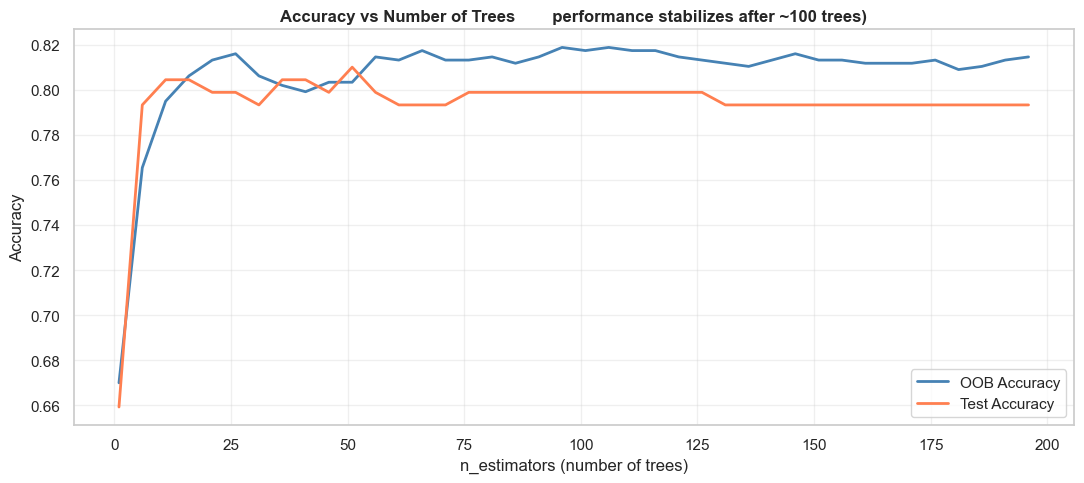

Performance stabilizes at approximately 46 trees.

Key insight: unlike boosting, adding more trees to a Random Forest
never hurts -- it only reduces variance further. But returns diminish
rapidly and computation cost grows linearly. 100-300 is usually enough.


In [7]:
n_estimators_range = range(1, 201, 5)
oob_scores, test_scores = [], []

for n_est in n_estimators_range:
    rf = RandomForestClassifier(
        n_estimators=n_est,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)
    test_scores.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(11, 5))
plt.plot(n_estimators_range, oob_scores,  color='steelblue', linewidth=2,
         label='OOB Accuracy')
plt.plot(n_estimators_range, test_scores, color='coral',     linewidth=2,
         label='Test Accuracy')
plt.xlabel('n_estimators (number of trees)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Trees ' \
'       performance stabilizes after ~100 trees)',
          fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find where improvement plateaus
improvements = np.diff(oob_scores)
plateau_idx  = next((i for i, v in enumerate(improvements) if abs(v) < 0.001), len(improvements))
plateau_n    = list(n_estimators_range)[plateau_idx]

print(f"Performance stabilizes at approximately {plateau_n} trees.")
print()
print("Key insight: unlike boosting, adding more trees to a Random Forest")
print("never hurts -- it only reduces variance further. But returns diminish")
print("rapidly and computation cost grows linearly. 100-300 is usually enough.")

## 4. Train and Evaluate

In [8]:
# GridSearchCV for optimal hyperparameters
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features':     ['sqrt', 'log2', 0.5],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True)

gs = GridSearchCV(
    rf_base, param_grid,
    cv=skf, scoring='roc_auc',
    n_jobs=-1
)
gs.fit(X_train, y_train)

print(f"Best parameters: {gs.best_params_}")
print(f"Best CV ROC-AUC: {gs.best_score_:.4f}")

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV ROC-AUC: 0.8871


In [9]:
best_rf = gs.best_estimator_
y_pred  = best_rf.predict(X_test)
y_prob  = best_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Classifier Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print(f"OOB Score: {best_rf.oob_score_:.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=['Did Not Survive', 'Survived']))

=== Random Forest Classifier Results ===
Accuracy:  0.7877
Precision: 0.7541
Recall:    0.6667
F1 Score:  0.7077
ROC-AUC:   0.8432
OOB Score: 0.8244

                 precision    recall  f1-score   support

Did Not Survive       0.81      0.86      0.83       110
       Survived       0.75      0.67      0.71        69

       accuracy                           0.79       179
      macro avg       0.78      0.77      0.77       179
   weighted avg       0.79      0.79      0.78       179



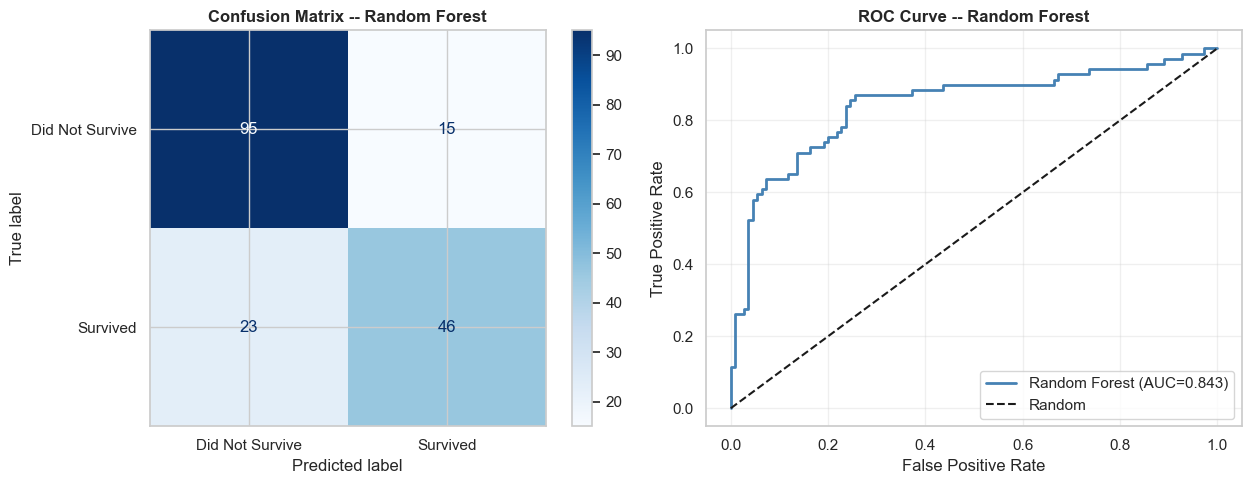

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix -- Random Forest', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'Random Forest (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve -- Random Forest', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Feature Importance -- Built-in and Permutation

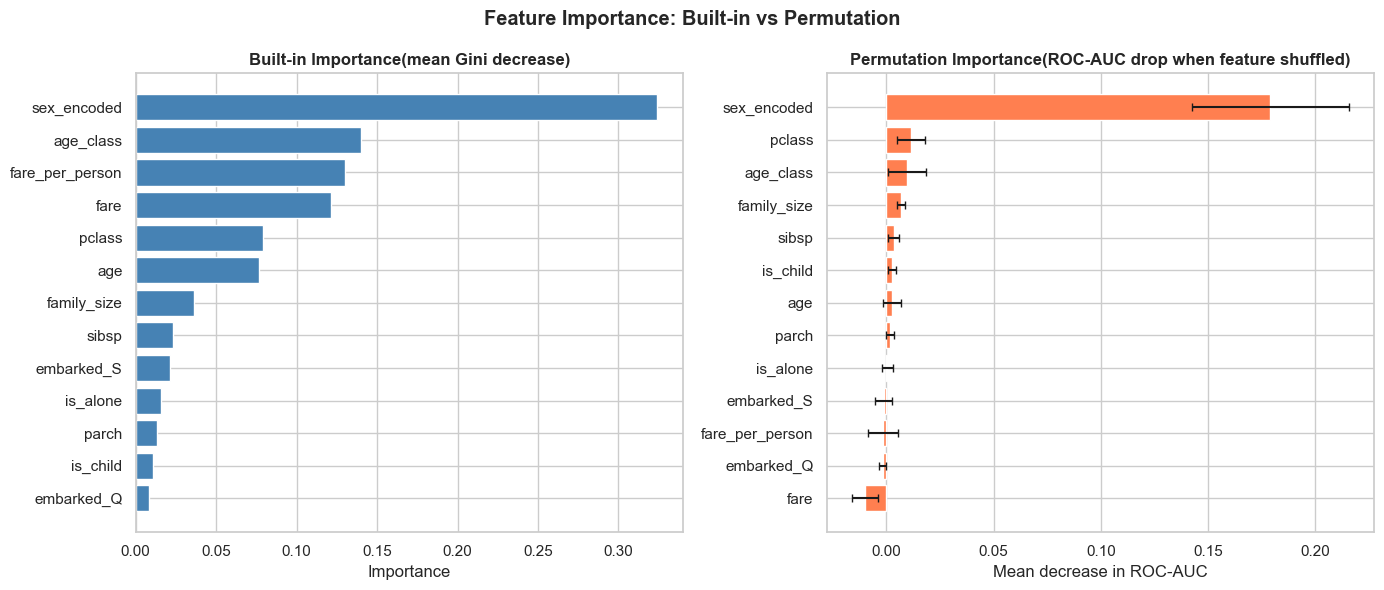

Built-in importance can overrate high-cardinality features.
Permutation importance is more reliable -- use it for final decisions.

Do both methods agree on the most important features?

Top 3 by built-in:      ['sex_encoded', 'age_class', 'fare_per_person']
Top 3 by permutation:   ['sex_encoded', 'pclass', 'age_class']


In [11]:
# Built-in importance (mean decrease in Gini impurity)
imp_builtin = pd.DataFrame({
    'feature':    feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

# Permutation importance (more reliable -- measures actual performance drop)
perm = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=20, random_state=42, scoring='roc_auc'
)
imp_perm = pd.DataFrame({
    'feature':    feature_cols,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(imp_builtin['feature'], imp_builtin['importance'],
             color='steelblue', edgecolor='white')
axes[0].set_title('Built-in Importance' '(mean Gini decrease)', fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

axes[1].barh(imp_perm['feature'], imp_perm['importance'],
             xerr=imp_perm['std'], color='coral',
             edgecolor='white', capsize=3)
axes[1].set_title('Permutation Importance'+
                  '(ROC-AUC drop when feature shuffled)',
                   fontweight='bold')
axes[1].set_xlabel('Mean decrease in ROC-AUC')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance: Built-in vs Permutation', fontweight='bold')
plt.tight_layout()
plt.show()

print("Built-in importance can overrate high-cardinality features.")
print("Permutation importance is more reliable -- use it for final decisions.")
print()
print("Do both methods agree on the most important features?")
print()
print("Top 3 by built-in:     ", imp_builtin['feature'].head(3).tolist())
print("Top 3 by permutation:  ", imp_perm['feature'].head(3).tolist())

## 6. Cross-Validation

In [12]:
cv_metrics = {
    'accuracy': cross_val_score(best_rf, X, y, cv=skf, scoring='accuracy'),
    'roc_auc':  cross_val_score(best_rf, X, y, cv=skf, scoring='roc_auc'),
    'f1':       cross_val_score(best_rf, X, y, cv=skf, scoring='f1'),
    'recall':   cross_val_score(best_rf, X, y, cv=skf, scoring='recall'),
}

print("5-Fold Stratified Cross-Validation -- Random Forest:")
print()
print(f"{'Metric':<12} {'Mean':>8} {'Std':>8}  Fold scores")
print("-" * 68)
for metric, scores in cv_metrics.items():
    folds = '  '.join([f'{s:.4f}' for s in scores])
    print(f"{metric:<12} {scores.mean():>8.4f} {scores.std():>8.4f}  {folds}")

5-Fold Stratified Cross-Validation -- Random Forest:

Metric           Mean      Std  Fold scores
--------------------------------------------------------------------
accuracy       0.8294   0.0229  0.8603  0.8315  0.7921  0.8202  0.8427
roc_auc        0.8818   0.0172  0.9084  0.8858  0.8625  0.8634  0.8888
f1             0.7634   0.0351  0.8092  0.7761  0.7040  0.7500  0.7778
recall         0.7192   0.0446  0.7681  0.7647  0.6471  0.7059  0.7101


## 7. Full Comparison 

In [13]:
# Retrain M2 and M4 on same data
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
pipe_lr.fit(X_train, y_train)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

models = {
    'Logistic Regression ': (pipe_lr, pipe_lr.predict(X_test),
                                  pipe_lr.predict_proba(X_test)[:,1]),
    'Decision Tree ':       (dt,      dt.predict(X_test),
                                  dt.predict_proba(X_test)[:,1]),
    'Random Forest ':      (best_rf, y_pred, y_prob),
}

print("=" * 68)
print("  Titanic Survival Classification")
print("=" * 68)
metrics_list = ['accuracy','precision','recall','f1','roc_auc']
print(f"{'Metric':<12}", end="")
for name in models:
    print(f"  {name:>25}", end="")
print()
print("-" * 88)

for metric in metrics_list:
    vals = []
    for name, (model, pred, prob) in models.items():
        if metric == 'accuracy':  vals.append(accuracy_score(y_test, pred))
        elif metric == 'precision': vals.append(precision_score(y_test, pred))
        elif metric == 'recall':    vals.append(recall_score(y_test, pred))
        elif metric == 'f1':        vals.append(f1_score(y_test, pred))
        elif metric == 'roc_auc':   vals.append(roc_auc_score(y_test, prob))

    best_val = max(vals)
    print(f"{metric:<12}", end="")
    for val in vals:
        flag = " *" if val == best_val else "  "
        print(f"  {val:>24.4f}{flag}", end="")
    print()

print()
print("* = best on that metric")

  Titanic Survival Classification
Metric             Logistic Regression              Decision Tree              Random Forest 
----------------------------------------------------------------------------------------
accuracy                        0.8268 *                    0.7877                      0.7877  
precision                       0.8276 *                    0.7627                      0.7541  
recall                          0.6957 *                    0.6522                      0.6667  
f1                              0.7559 *                    0.7031                      0.7077  
roc_auc                         0.8589 *                    0.7908                      0.8432  

* = best on that metric


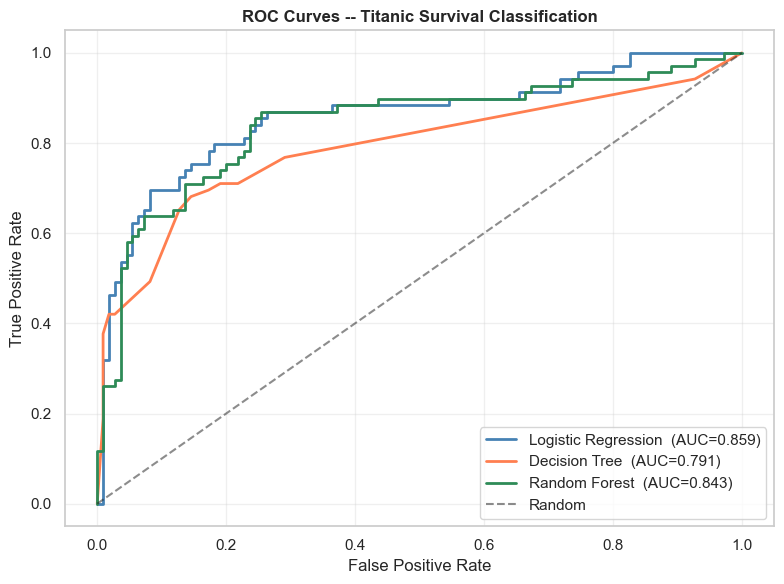

The classification chain on Titanic is now complete.
Each model added more flexibility while reducing variance.


In [14]:
# ROC curves -- all three
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'coral', 'seagreen']
for (name, (model, pred, prob)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves -- Titanic Survival Classification',
          fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The classification chain on Titanic is now complete.")
print("Each model added more flexibility while reducing variance.")

## Summary

**What Random Forest adds over a single Decision Tree:**
- Lower variance -- averaging hundreds of diverse trees cancels individual errors
- More stable feature importance -- computed across all trees, not just one
- Built-in validation via OOB samples -- no need for a separate validation split
- More robust to outliers and noise in the training data

**What Random Forest does NOT add over XGBoost:**
- It trains trees independently (parallel), not sequentially (boosting)
- It cannot correct systematic errors the way boosting can
- On most tabular datasets, a tuned XGBoost outperforms a tuned Random Forest
- XGBoost tends to win on Kaggle; Random Forest tends to be more stable and easier to tune

**When to prefer Random Forest over XGBoost:**
- You need faster training (Random Forest parallelizes perfectly)
- You want OOB validation without a separate split
- The dataset is noisy -- boosting can overfit noise more easily
- You want a reliable strong baseline before trying XGBoost

**When to prefer XGBoost:**
- Maximum accuracy on tabular data
- You have time to tune learning_rate and n_estimators properly
- You are submitting to Kaggle
